In [1]:
import nibabel as nib
import matplotlib.pyplot as plt

/Users/rumethsandinu/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Text(0.5, 1.0, 'Mask')

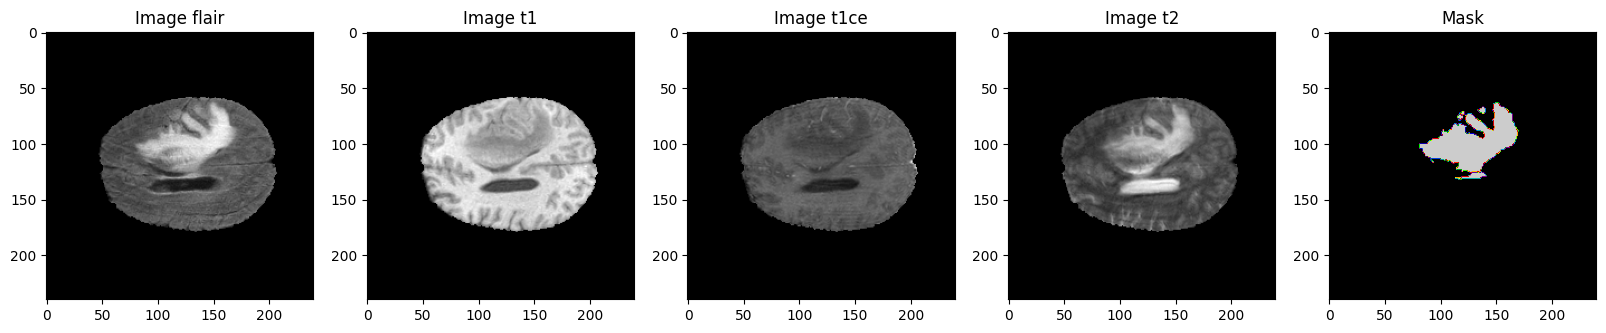

In [2]:
TRAIN_DATASET_PATH = '../../BraTS20/'

test_image_flair=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_flair.nii').get_fdata()
test_image_t1=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_t1.nii').get_fdata()
test_image_t1ce=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_t1ce.nii').get_fdata()
test_image_t2=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_t2.nii').get_fdata()
test_mask=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_seg.nii').get_fdata()


fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1,5, figsize = (20, 10))
slice_w = 25
ax1.imshow(test_image_flair[:,:,test_image_flair.shape[0]//2-slice_w], cmap = 'gray')
ax1.set_title('Image flair')
ax2.imshow(test_image_t1[:,:,test_image_t1.shape[0]//2-slice_w], cmap = 'gray')
ax2.set_title('Image t1')
ax3.imshow(test_image_t1ce[:,:,test_image_t1ce.shape[0]//2-slice_w], cmap = 'gray')
ax3.set_title('Image t1ce')
ax4.imshow(test_image_t2[:,:,test_image_t2.shape[0]//2-slice_w], cmap = 'gray')
ax4.set_title('Image t2')

# ax5.imshow(test_mask[:,:,test_mask.shape[0]//2-slice_w])
ax5.imshow(test_mask[:,:,test_mask.shape[0]//2-slice_w], cmap='nipy_spectral')

ax5.set_title('Mask')

In [3]:
import cv2
import numpy as np

In [4]:
# pick slice with maximum tumor area
mask_area_per_slice = test_mask.sum(axis=(0, 1))
if np.any(mask_area_per_slice > 0):
    slice_idx = int(np.argmax(mask_area_per_slice))
else:
    slice_idx = int(test_image_t2.shape[2] // 2)

# extract slice and binarize mask (>0)
img = test_image_flair[:, :, slice_idx].astype(np.float32)
mask_slice = (test_mask[:, :, slice_idx] > 0).astype(np.uint8) * 255

# mormalize image to 0-255 uint8 for OpenCV
img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
height, width = img.shape
print(f"Sample slice {slice_idx} loaded: shape {img.shape}, tumor pixels: {int(mask_slice.sum()//255)}")

Sample slice 68 loaded: shape (240, 240), tumor pixels: 5040


### Anisotropic Diffusion Filter

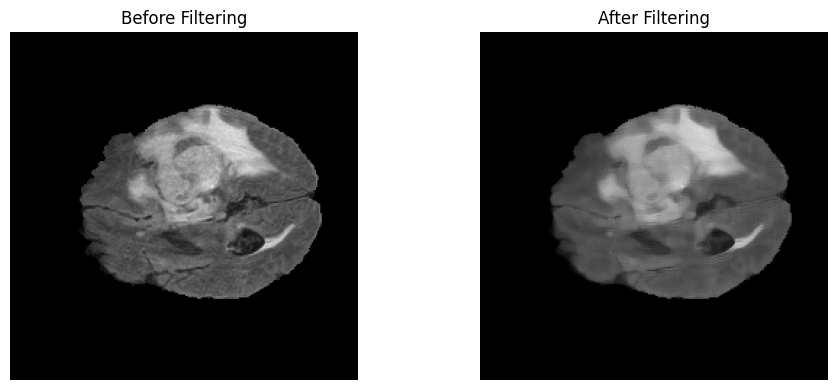

In [5]:
# anisotropic diffusion filter

def _grad_xy(u):

    # horizontal gradients
    gx = np.zeros_like(u, dtype=np.float32)

    # vertical gradients
    gy = np.zeros_like(u, dtype=np.float32)

    # approximate gradients using two neighours
    gx[:, 1:-1] = 0.5 * (u[:, 2:] - u[:, :-2])

    # approximate gradients for the right boundary
    gx[:, 0] = u[:, 1] - u[:, 0]

    # approximate gradients for the left boundary
    gx[:, -1] = u[:, -1] - u[:, -2]

    # verticl gradient approximation
    gy[1:-1, :] = 0.5 * (u[2:, :] - u[:-2, :])
    gy[0, :] = u[1, :] - u[0, :]
    gy[-1, :] = u[-1, :] - u[-2, :]
    return gx, gy


def _div(nx, ny):

    # horizontal divergence
    dx = np.zeros_like(nx, dtype=np.float32)

    # vertical divergence
    dy = np.zeros_like(ny, dtype=np.float32)

    # approximate gradients with backword difference
    dx[:, 1:-1] = nx[:, 1:-1] - nx[:, 0:-2]

    # set gradient 0 for left boundary
    dx[:, 0] = 0.0

    # right most column backword difference
    dx[:, -1] = nx[:, -1] - nx[:, -2]

    # vertical gradient calculation
    dy[1:-1, :] = ny[1:-1, :] - ny[0:-2, :]
    dy[0, :] = 0.0
    dy[-1, :] = ny[-1, :] - ny[-2, :]

    # return scaler field with some of the gradients
    return dx + dy


def anisotropic_diffusion(
    img,
    num_iter=15,

    # control sensitiviy to gradients
    k=25.0,

    # time-step scaling factor
    gamma=0.1,

    # gaussian pre-smoothing for g(|∇(Gσ*u)|)
    sigma=1.0
):
    """
    Implements anisotropic diffusion:
    - model='alvarez': ∂u/∂t = g(|∇(Gσ*u)|) * |∇u| * div(∇u/|∇u|)
      (Selective smoothing via mean-curvature motion with edge-stopping g)
    - model='pm': Perona–Malik with exponential/reciprocal conduction.
    Zero-flux (Neumann) boundary conditions.
    """
    u = img.astype(np.float32)
    gamma = float(min(gamma, 0.25))
    eps = 1e-6

    
    def g_func(s):
        return np.exp(- (s / k) ** 2)

    for _ in range(num_iter):

        # pre-smooth for robust edge detection in g(|∇(Gσ*u)|)
        u_blur = cv2.GaussianBlur(u, ksize=(0, 0), sigmaX=sigma, sigmaY=sigma)
        gx_b, gy_b = _grad_xy(u_blur)
        mag_b = np.sqrt(gx_b * gx_b + gy_b * gy_b) + eps
        g = g_func(mag_b)

        # geometric terms on the current image u
        gx, gy = _grad_xy(u)
        mag = np.sqrt(gx * gx + gy * gy) + eps
        nx = gx / mag
        ny = gy / mag
        curvature = _div(nx, ny)

        u += gamma * (g * mag * curvature)
        
    return np.clip(u, 0, 255).astype(np.uint8)

# apply the filter to sample image
img_before = img.copy()
img = anisotropic_diffusion(img, num_iter=20, k=25, gamma=0.1, sigma=1.0)
img_after = img

# plot results
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_before.astype(np.uint8), cv2.COLOR_GRAY2RGB))
plt.title('Before Filtering')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_after.astype(np.uint8), cv2.COLOR_GRAY2RGB))
plt.title('After Filtering')
plt.axis('off')
plt.tight_layout()
plt.show()

### Threshold to find bright seed points

In [6]:
ret, th = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
indexes = [(j, i) for j in range(height) for i in range(width) if th[j, i] == 255]

# choose the brightest pixel as seed for better tumor detection
seed_intensities = [img[j, i] for (j, i) in indexes]

# pixel with max intensity
seed = indexes[np.argmax(seed_intensities)]
print('Seed point:', seed)

Seed point: (106, 139)


### Region Growing Function
- Initialize a seed point
- Neighbour pixels with similar characteristics which satisfy the growth criteria would be merged
- This searching and merging process will be iterated until there are no pixels to merge


In [7]:
def region_growing(img, seed, region_threshold=41):
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    height, width = img.shape
    segmented_img = np.zeros((height, width), np.uint8)

    # start region with seed
    region_mean = float(img[seed])
    region_size = 1
    neighbor_points_list = [seed]

    while neighbor_points_list:
        current_pixel = neighbor_points_list.pop(0)
        x, y = current_pixel
        segmented_img[x, y] = 255

        for dx, dy in neighbors:
            xn, yn = x + dx, y + dy
            if 0 <= xn < height and 0 <= yn < width and segmented_img[xn, yn] == 0:
                intensity_diff = abs(int(img[xn, yn]) - region_mean)
                if intensity_diff <= region_threshold:
                    segmented_img[xn, yn] = 255
                    neighbor_points_list.append((xn, yn))

                    # update region mean
                    region_mean = (region_mean * region_size + int(img[xn, yn])) / (region_size + 1)
                    region_size += 1

    return segmented_img

### Segment and Highlight Tumor

In [8]:
# threhold value: 47
segmented_img = region_growing(img, seed, region_threshold=47)

highlighted = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
highlighted[segmented_img == 255] = [0, 0, 255]

### Display Results

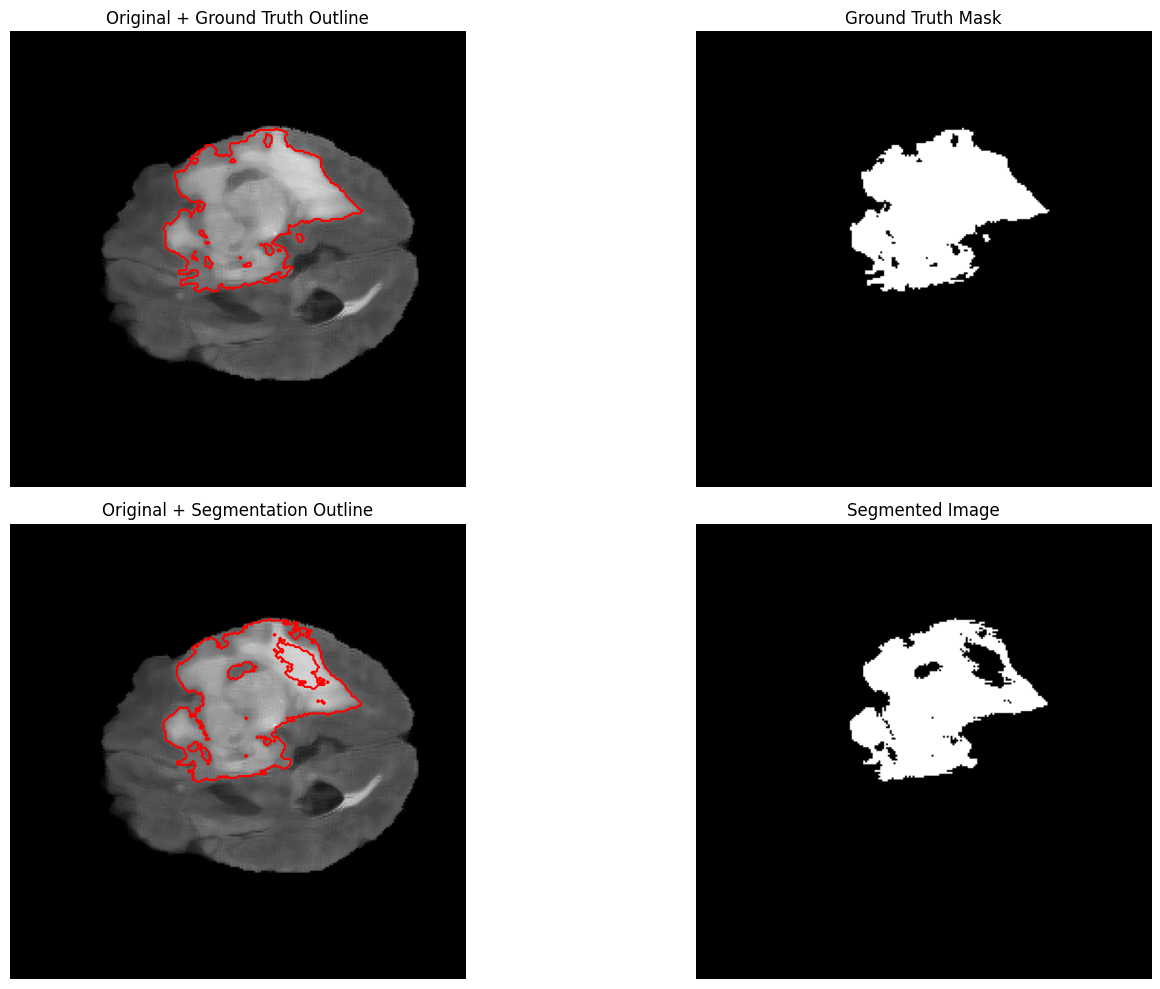

In [9]:
# plot results

img_display = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
segmented_display = cv2.cvtColor(segmented_img, cv2.COLOR_GRAY2RGB)

# ground truth mask to RGB
gt_display = cv2.cvtColor(mask_slice, cv2.COLOR_GRAY2RGB)

# binary masks for contours
gt_bin = (mask_slice > 0).astype(np.uint8)
seg_bin = (segmented_img > 0).astype(np.uint8)

plt.figure(figsize=(16, 10))

# Original + Groud Truth Outline
plt.subplot(2, 2, 1)
plt.imshow(img_display)
plt.contour(gt_bin, levels=[0.5], colors='red', linewidths=1.5)
plt.title('Original + Ground Truth Outline')
plt.axis('off')

# Ground Truth Mask
plt.subplot(2, 2, 2)
plt.imshow(gt_display)
plt.title('Ground Truth Mask')
plt.axis('off')

# Original + Segmentation outline
plt.subplot(2, 2, 3)
plt.imshow(img_display)
plt.contour(seg_bin, levels=[0.5], colors='red', linewidths=1.5)
plt.title('Original + Segmentation Outline')
plt.axis('off')

# Segmented Image
plt.subplot(2, 2, 4)
plt.imshow(segmented_display)
plt.title('Segmented Image')
plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
# adaptive model

# calculate weight coefficients (alpha, beta)

delta = 10.0
alpha_beta_ratio = delta / (2 * (np.pi**2))
beta = 1.0 / (1.0 + alpha_beta_ratio)
alpha = 1.0 - beta
print(f"Calculated weights: alpha={alpha:.3f}, beta={beta:.3f}")

# calculate gradient magnitude Iimage
grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)

# iterate thresholds to find minimum h
thresholds_to_test = range(10, 70, 1)
results = []
min_h = float('inf')
optimal_segmentation = np.zeros_like(img)
optimal_threshold = 0

for T in thresholds_to_test:
    # get coarse contour by running region growing
    segmented_mask = region_growing(img, seed, region_threshold=T)

    # skip if segmentation failed or segmented the whole image
    if np.sum(segmented_mask) == 0:
        continue

    # find the boundary curve
    contours, _ = cv2.findContours(segmented_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        continue
        
    contour_mask = np.zeros_like(segmented_mask)
    cv2.drawContours(contour_mask, contours, -1, (255), 1)

    # calculate sigma_s: mean variance inside the boundary
    pixels_inside = img[segmented_mask == 255]
    if pixels_inside.size < 2:
        continue
    sigma_s = np.var(pixels_inside)

    # calculate G_s: reciprocal of mean gradient along the boundary
    pixels_on_contour = gradient_magnitude[contour_mask == 255]
    if pixels_on_contour.size == 0:
        continue
        
    g_s = np.mean(pixels_on_contour)
    if g_s == 0:
        continue
    G_s = 1.0 / g_s

    # calculate the objective function h 
    h = (alpha * G_s) + (beta * sigma_s)
    results.append({'T': T, 'h': h})

    # find the minimum h and corresponding threshold
    if h < min_h:
        min_h = h
        optimal_threshold = T
        optimal_segmentation = segmented_mask

print(f"Optimal threshold found: T = {optimal_threshold} (with min h = {min_h:.4f})")

Calculated weights: alpha=0.336, beta=0.664
Optimal threshold found: T = 47 (with min h = 398.7173)


In [11]:
# use the best segmentation found by the model
segmented_image = optimal_segmentation

# highlight the segmented area
highlighted = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
highlighted[segmented_image == 255] = [0, 0, 255]

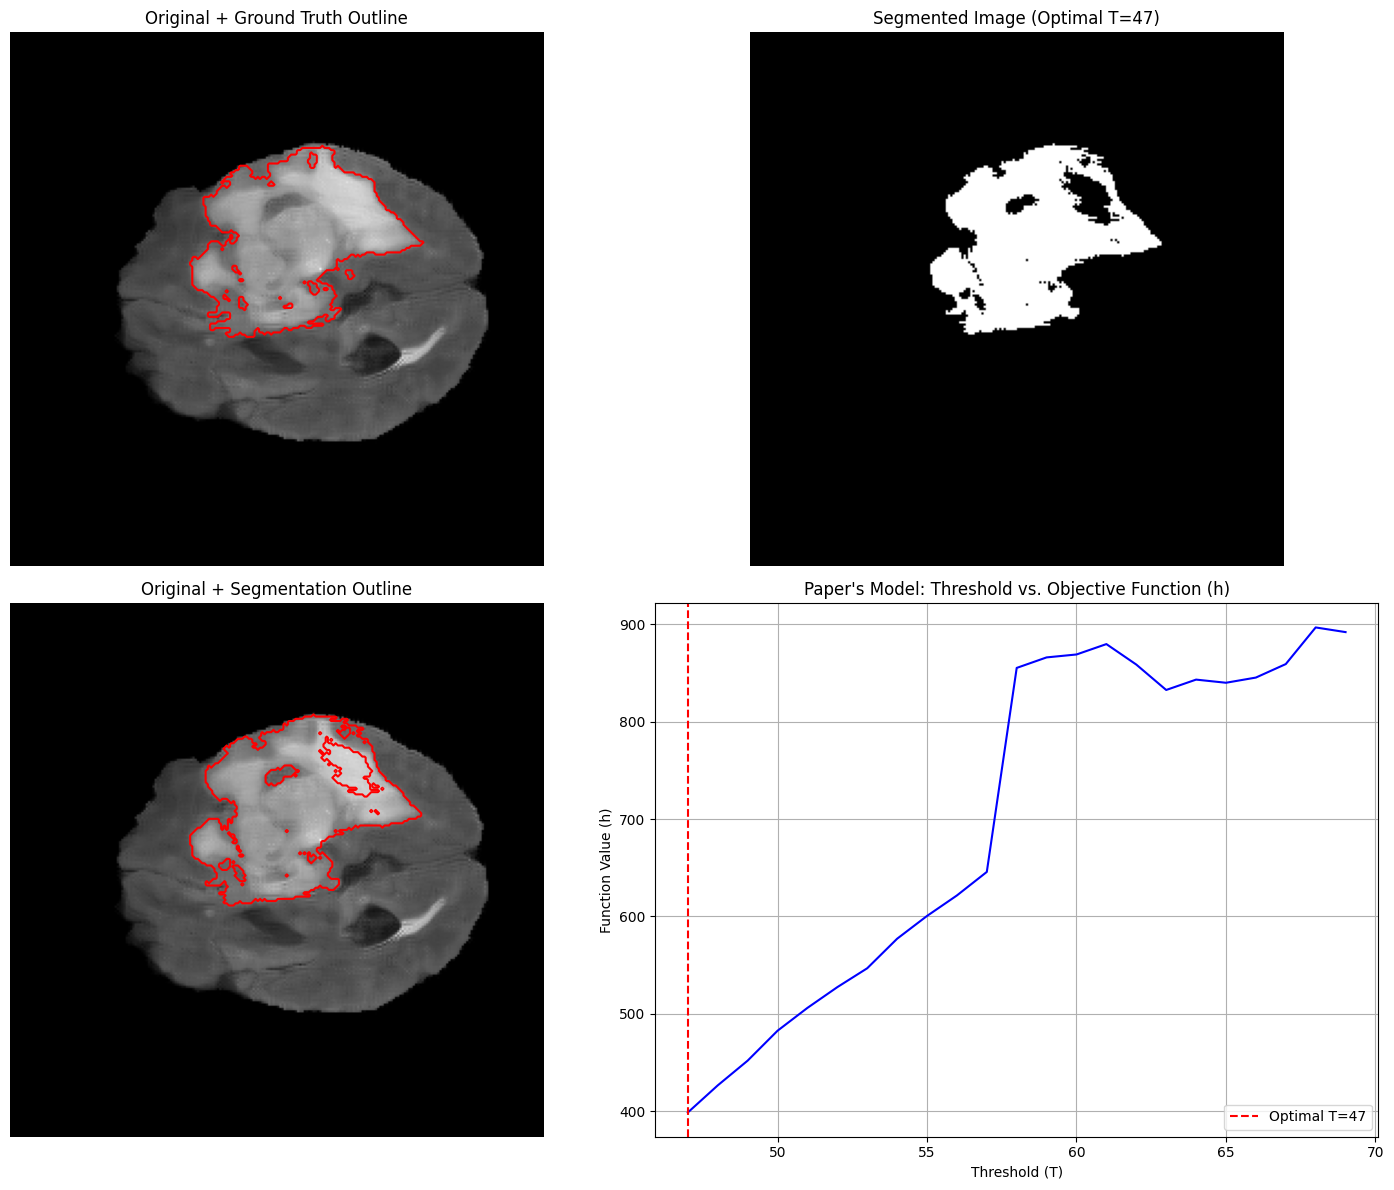

In [12]:
# plot sample

# color space conversion
img_display = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
segmented_display = cv2.cvtColor(segmented_image, cv2.COLOR_GRAY2RGB)
# ground truth mask for overlays
gt_mask_bin = (mask_slice > 0).astype(np.uint8)
# segmentation mask binary for outline
seg_mask_bin = (segmented_image > 0).astype(np.uint8)

plt.figure(figsize=(15, 12))

# Original Image + Groud Truth Outline
plt.subplot(2, 2, 1)
plt.imshow(img_display)
plt.contour(gt_mask_bin, levels=[0.5], colors='red', linewidths=1.5)
plt.title('Original + Ground Truth Outline')
plt.axis('off')

# Segmented Image
plt.subplot(2, 2, 2)
plt.imshow(segmented_display)
plt.title(f'Segmented Image (Optimal T={optimal_threshold})')
plt.axis('off')

# Original Image + Segmentation outline
plt.subplot(2, 2, 3)
plt.imshow(img_display)
plt.contour(seg_mask_bin, levels=[0.5], colors='red', linewidths=1.5)
plt.title('Original + Segmentation Outline')
plt.axis('off')

# Plot of Threshold vs. Objective Function
threshold_vals = [r['T'] for r in results]
h_vals = [r['h'] for r in results]

plt.subplot(2, 2, 4)
plt.plot(threshold_vals, h_vals, 'b-')
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal T={optimal_threshold}')
plt.title("Paper's Model: Threshold vs. Objective Function (h)")
plt.xlabel('Threshold (T)')
plt.ylabel('Function Value (h)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Apply the Filter and Segment the Samples

In [13]:
import glob
import os
from tqdm.auto import tqdm
from math import pi
import time

/Users/rumethsandinu/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
# configs
ALL_CASES_PATH = TRAIN_DATASET_PATH.rstrip("/") + "/"
use_modality = "flair"

# apply anisotropic filter to all the training images
def apply_anisotropic_filter_to_all(all_cases_path, modality="t2", num_iter=20, k=25, gamma=0.1, sigma=1.0):
    case_dirs = sorted([d for d in glob.glob(os.path.join(all_cases_path, "BraTS20_Training_*")) 
                        if os.path.isdir(d)])
    if not case_dirs:
        raise FileNotFoundError(f"No case folders found in: {all_cases_path}")

    # store intensity distributions
    filtered = []
    stats_list = []
    pbar = tqdm(case_dirs, desc="Filtering", unit="case")

    for case_dir in pbar:
        case_id = os.path.basename(case_dir)
        mod_glob = glob.glob(os.path.join(case_dir, f"{case_id}_{modality}.nii*"))
        seg_glob = glob.glob(os.path.join(case_dir, f"{case_id}_seg.nii*"))
        if not mod_glob or not seg_glob:
            continue
        mod_path = mod_glob[0]
        seg_path = seg_glob[0]

        vol = nib.load(mod_path).get_fdata().astype(np.float32)
        seg = nib.load(seg_path).get_fdata().astype(np.float32)

        areas = seg.sum(axis=(0, 1))

        # keep the slice with maximum tumor area of each case
        if np.any(areas > 0):
            k_slice = int(np.argmax(areas))
        else:
            k_slice = vol.shape[2] // 2

        img_slice_f = vol[:, :, k_slice]
        mask_slice = (seg[:, :, k_slice] > 0).astype(np.uint8) * 255

        img_u8 = cv2.normalize(img_slice_f, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        # apply filter with timing
        t0 = time.perf_counter()
        img_filt = anisotropic_diffusion(
            img_u8,
            num_iter=num_iter,
            k=k,
            gamma=gamma,
            sigma=sigma
        )
        t1 = time.perf_counter()
        filt_dt = t1 - t0

        # store stats
        stats_list.append({
            "case": case_id,
            "slice": k_slice,
            "mean": float(img_filt.mean()),
            "std": float(img_filt.std())
        })

        filtered.append({
            "case": case_id,
            "slice": k_slice,
            "mod": modality,
            "img_orig": img_u8,
            "img_filt": img_filt,
            "mask_slice": mask_slice,
            "filter_time_s": float(filt_dt),
            "filter_num_iter": int(num_iter)
        })

    print('\nSuccessfully applied anisotropic diffusion filter to all traning images')
    return filtered, stats_list


def segment_cases(filtered_cases, delta=10.0):
    alpha_beta_ratio = delta / (2 * (pi**2))
    beta = 1.0 / (1.0 + alpha_beta_ratio)
    alpha = 1.0 - beta

    segmented = []
    pbar = tqdm(filtered_cases, desc="Segmentation", unit="case")
    for item in pbar:
        img_filt = item["img_filt"]
        mask_slice = item["mask_slice"]

        # seed selection (brightest in binary threshold)
        _, th = cv2.threshold(img_filt, 127, 255, cv2.THRESH_BINARY)
        hgt, wdt = img_filt.shape
        idxs = [(j, i) for j in range(hgt) for i in range(wdt) if th[j, i] == 255]
        if idxs:
            seed_vals = [img_filt[j, i] for (j, i) in idxs]
            seed = idxs[int(np.argmax(seed_vals))]
        else:
            flat_idx = int(np.argmax(img_filt))
            seed = (flat_idx // wdt, flat_idx % wdt)

        # segmentation timing begins
        t0 = time.perf_counter()

        # gradient magnitude for boundary term
        gx = cv2.Sobel(img_filt, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(img_filt, cv2.CV_64F, 0, 1, ksize=3)
        grad_mag = np.sqrt(gx*gx + gy*gy)

        # adaptive threshold search
        min_h = float('inf')
        best_T = None
        best_mask = None
        tested_count = 0
        for T in range(10, 70, 1):
            seg_mask = region_growing(img_filt, seed, region_threshold=T)
            if np.sum(seg_mask) == 0:
                continue
            contours, _ = cv2.findContours(seg_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            if not contours:
                continue
            tested_count += 1
            contour_mask = np.zeros_like(seg_mask)
            cv2.drawContours(contour_mask, contours, -1, (255), 1)

            inside = img_filt[seg_mask == 255]
            if inside.size < 2:
                continue
            sigma_s = np.var(inside)

            on_boundary = grad_mag[contour_mask == 255]
            if on_boundary.size == 0:
                continue
            g_s = np.mean(on_boundary)
            if g_s == 0:
                continue
            G_s = 1.0 / g_s

            h = (alpha * G_s) + (beta * sigma_s)
            if h < min_h:
                min_h = h
                best_T = T
                best_mask = seg_mask

        if best_mask is None:
            best_T = 41
            best_mask = region_growing(img_filt, seed, region_threshold=best_T)

        t1 = time.perf_counter()
        seg_dt = t1 - t0

        segmented.append({
            **item,
            "best_T": int(best_T),
            "best_mask": best_mask,
            "segment_time_s": float(seg_dt),
            "tested_Ts": int(tested_count)
        })

    return segmented

## Flair

In [15]:
filtered_cases, stats_list = apply_anisotropic_filter_to_all(
    ALL_CASES_PATH, use_modality, num_iter=20, k=25, gamma=0.1, sigma=1.0)

segmented_cases = segment_cases(filtered_cases, delta=10.0)

Filtering: 100%|██████████| 369/369 [00:29<00:00, 12.37case/s]



Successfully applied anisotropic diffusion filter to all traning images


Segmentation: 100%|██████████| 368/368 [06:57<00:00,  1.13s/case]


In [16]:
# mean inference time

# mean times
filt_times = [c.get('filter_time_s', np.nan) for c in filtered_cases]
seg_times  = [c.get('segment_time_s', np.nan) for c in segmented_cases]

filt_times = np.array([t for t in filt_times if not np.isnan(t)])
seg_times  = np.array([t for t in seg_times if not np.isnan(t)])

mean_filter_time_ms  = (filt_times.mean()*1000.0) if filt_times.size else float('nan')
mean_segment_time_ms = (seg_times.mean()*1000.0) if seg_times.size else float('nan')
mean_total_time_ms   = mean_filter_time_ms + mean_segment_time_ms

print(f"Mean inference time per sample: {mean_total_time_ms:.2f} ms")
print(f"filter: {mean_filter_time_ms:.2f} ms, Segment: {mean_segment_time_ms:.2f} ms")

Mean inference time per sample: 1102.64 ms
filter: 9.92 ms, Segment: 1092.72 ms


### Results

In [17]:
import pandas as pd

Training slice count: 368


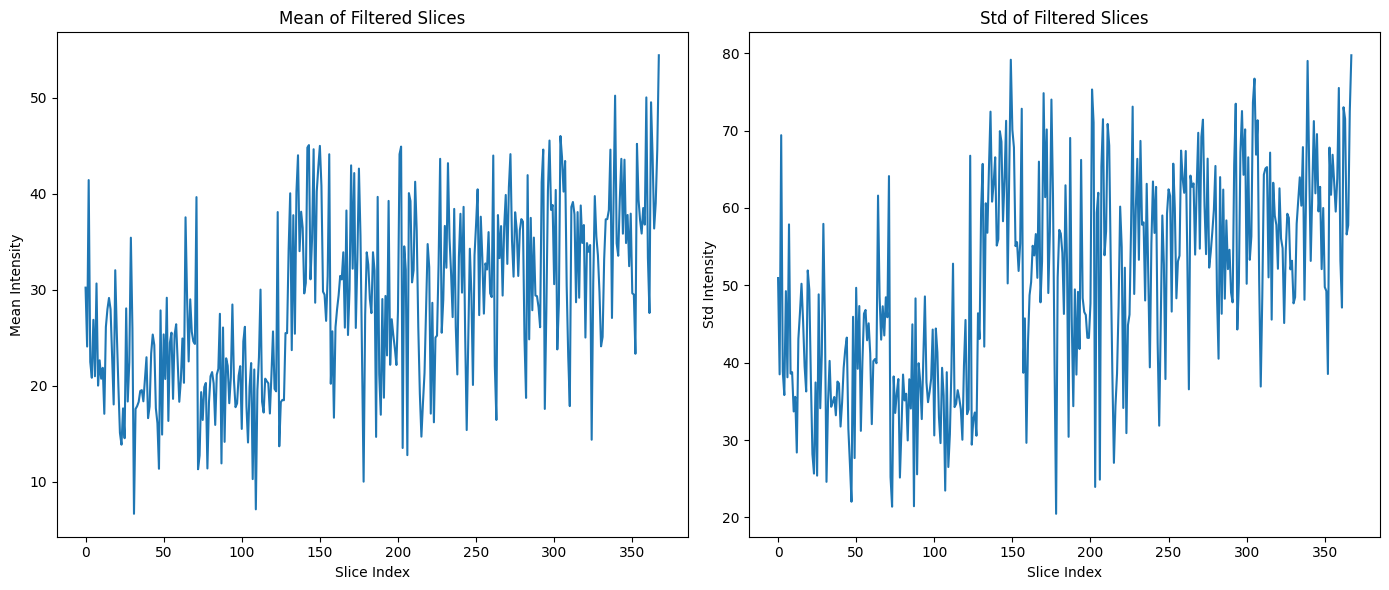

In [18]:
df = pd.DataFrame(stats_list)

print('Training slice count:', df.shape[0])

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(df["mean"])
plt.title("Mean of Filtered Slices")
plt.xlabel("Slice Index")
plt.ylabel("Mean Intensity")

plt.subplot(1,2,2)
plt.plot(df["std"])
plt.title("Std of Filtered Slices")
plt.xlabel("Slice Index")
plt.ylabel("Std Intensity")

plt.tight_layout()
plt.show()

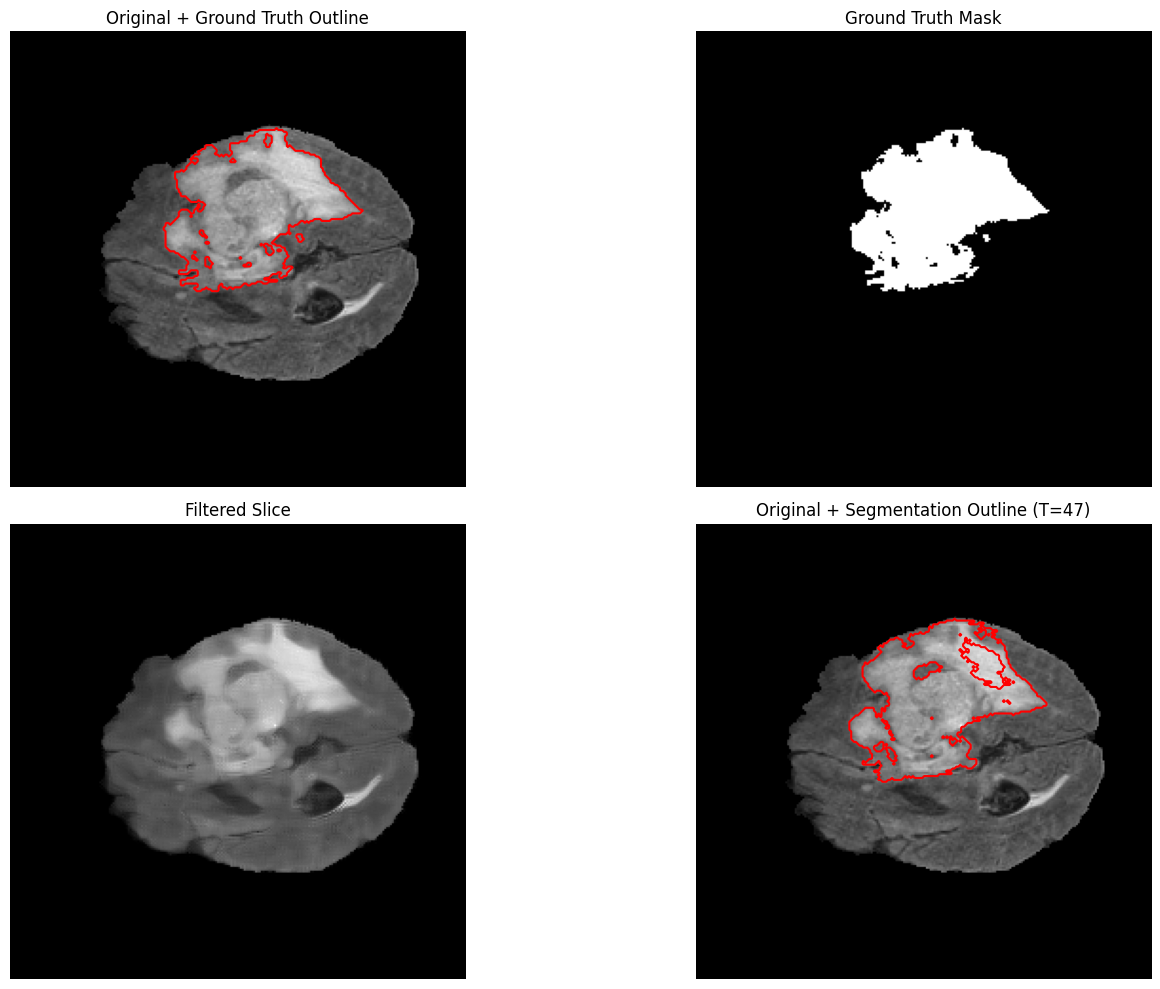

In [19]:
# visualize the first segmented case

# ensure we have at least one segmented case
if len(segmented_cases) == 0:
    print("No segmented cases available to plot")
else:
    sample = segmented_cases[0]
    img_orig = sample["img_orig"]
    img_filt = sample["img_filt"]
    gt_mask  = sample["mask_slice"]
    best_mask = sample["best_mask"]
    best_T = sample.get("best_T", None)

    # binary versions for contours
    gt_bin = (gt_mask > 0).astype(np.uint8)
    seg_bin = (best_mask > 0).astype(np.uint8)

    plt.figure(figsize=(16, 10))

    # Original + Ground Truth Outline
    plt.subplot(2, 2, 1)
    plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_GRAY2RGB))
    plt.contour(gt_bin, levels=[0.5], colors='red', linewidths=1.5)
    plt.title("Original + Ground Truth Outline")
    plt.axis('off')

    # Ground Truth Mask
    plt.subplot(2, 2, 2)
    plt.imshow(cv2.cvtColor(gt_mask, cv2.COLOR_GRAY2RGB))
    plt.title("Ground Truth Mask")
    plt.axis('off')

    # Filtered slice
    plt.subplot(2, 2, 3)
    plt.imshow(img_filt, cmap='gray')
    plt.title("Filtered Slice")
    plt.axis('off')

    # Original + Segmentation Outline
    plt.subplot(2, 2, 4)
    plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_GRAY2RGB))
    plt.contour(seg_bin, levels=[0.5], colors='red', linewidths=1.5)
    plt.title(f"Original + Segmentation Outline (T={best_T})")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

### Evaluation Pipeline

In [20]:
from scipy.ndimage import binary_erosion, distance_transform_edt

In [21]:
def dice_coefficient(y_true, y_pred, eps=1e-7):
    """
    y_true, y_pred: binary masks (0/1 or False/True)
    """
    y_true = np.asarray(y_true).astype(bool)
    y_pred = np.asarray(y_pred).astype(bool)
    
    intersection = np.logical_and(y_true, y_pred).sum()
    return (2.0 * intersection + eps) / (y_true.sum() + y_pred.sum() + eps)


def jaccard_index_iou(y_true, y_pred, eps=1e-7):
    """
    Jaccard Index (IoU) for binary masks.
    """
    y_true = np.asarray(y_true).astype(bool)
    y_pred = np.asarray(y_pred).astype(bool)
    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()
    return (intersection + eps) / (union + eps)


def normalized_surface_dice(pred, gt, tolerance=2):
    """
    Normalized Surface Dice (NSD) for 2D masks.

    pred, gt: binary masks (0/1 or False/True)
    tolerance: distance threshold in pixels (≈ mm if spacing=1mm)
    """
    pred = np.asarray(pred).astype(bool)
    gt   = np.asarray(gt).astype(bool)

    # handle empty cases
    if pred.sum() == 0 and gt.sum() == 0:
        return 1.0
    if pred.sum() == 0 or gt.sum() == 0:
        return 0.0

    struct = np.ones((3, 3), dtype=bool)

    # extract 1-pixel wide boundary (surface) of each mask
    pred_surface = np.logical_xor(
        pred, binary_erosion(pred, structure=struct, border_value=0)
    )
    gt_surface = np.logical_xor(
        gt, binary_erosion(gt, structure=struct, border_value=0)
    )

    if pred_surface.sum() == 0 or gt_surface.sum() == 0:
        return 0.0

    # distance transform of GT surface: distance to nearest GT boundary
    dist_map = distance_transform_edt(~gt_surface)

    # distances from predicted surface pixels to GT surface
    distances = dist_map[pred_surface]

    if distances.size == 0:
        return 0.0

    # fraction within tolerance
    nsd = np.mean(distances <= tolerance)
    return float(nsd)


In [22]:
# evaluate segmented cases using Dice, IoU (Jaccard), and NSD

# initialize results_df2 as empty DataFrame to ensure it always exists
results_df2 = pd.DataFrame(columns=["case", "slice", "best_T", "dice", "iou", "nsd"])

# ensure segmented_cases exists and is not empty
if 'segmented_cases' not in globals() or not segmented_cases:
    print("No segmented cases found. Please run the segmentation pipeline first.")
else:
    eval_results = []
    count_considered = 0

    for sample in segmented_cases:
        gt_mask = (sample["mask_slice"] > 0).astype(np.uint8)
        pred_mask = (sample["best_mask"] > 0).astype(np.uint8)

        # skip slices with empty GT to avoid skewing evaluation
        if gt_mask.sum() == 0:
            continue

        count_considered += 1

        dsc = dice_coefficient(gt_mask, pred_mask)
        iou = jaccard_index_iou(gt_mask, pred_mask)
        nsd = normalized_surface_dice(pred_mask, gt_mask, tolerance=2)

        eval_results.append({
            "case": sample["case"],
            "slice": sample["slice"],
            "best_T": sample.get("best_T", None),
            "dice": dsc,
            "iou": iou,
            "nsd": nsd
        })

    results_df2 = pd.DataFrame(eval_results)

    print(f"Samples considered for evaluation: {count_considered}")
    if count_considered == 0:
        print("No samples with non-empty ground truth; skipping stats.")
    else:
        print(results_df2.describe())
        means = results_df2[["dice", "iou", "nsd"]].mean()
        print(f"\nMeans -- Dice: {means['dice']:.4f}, IoU: {means['iou']:.4f}, NSD: {means['nsd']:.4f}")

Samples considered for evaluation: 368
            slice      best_T          dice           iou         nsd
count  368.000000  368.000000  3.680000e+02  3.680000e+02  368.000000
mean    78.108696   18.845109  1.856823e-01  1.292544e-01    0.174249
std     17.469604   13.269597  2.435267e-01  2.042312e-01    0.271063
min     22.000000   10.000000  2.074689e-11  2.074689e-11    0.000000
25%     64.000000   10.000000  4.967902e-03  2.490137e-03    0.000000
50%     79.000000   10.000000  8.268305e-02  4.312437e-02    0.011744
75%     91.000000   24.250000  2.578890e-01  1.480352e-01    0.248836
max    128.000000   64.000000  9.525078e-01  9.093220e-01    1.000000

Means -- Dice: 0.1857, IoU: 0.1293, NSD: 0.1742


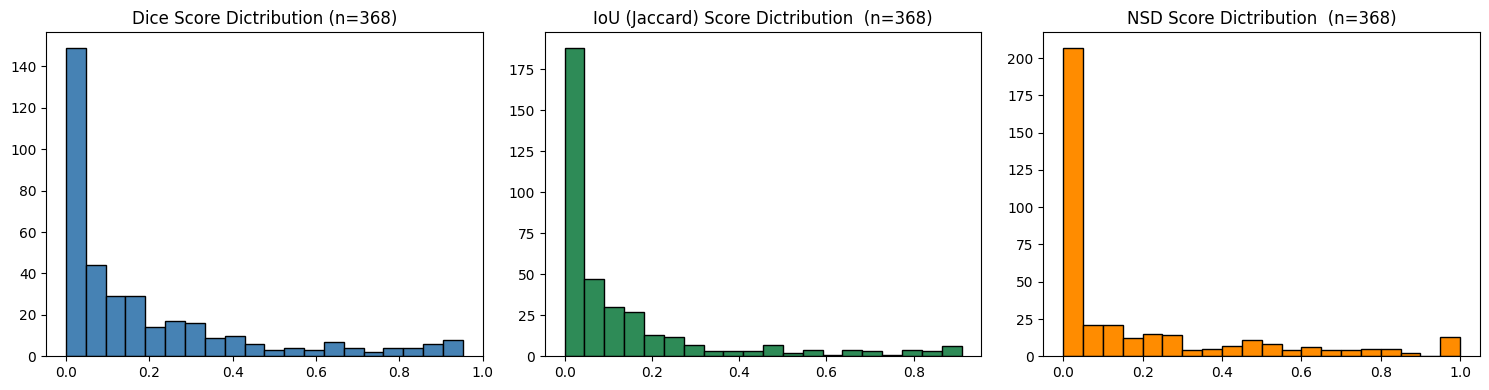

In [23]:
# histogram plots for evaluation metrics

# only proceed if results_df2 exists and has data
try:
    if results_df2 is None or results_df2.empty:
        raise ValueError("Empty results")
    n = len(results_df2)
except (NameError, ValueError):
    print("No evaluation results to plot histograms. Run the evaluation cell first.")
else:
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.hist(results_df2["dice"], bins=20, color='steelblue', edgecolor='black')
    plt.title(f"Dice Score Dictribution (n={n})")

    plt.subplot(1, 3, 2)
    plt.hist(results_df2["iou"], bins=20, color='seagreen', edgecolor='black')
    plt.title(f"IoU (Jaccard) Score Dictribution  (n={n})")

    plt.subplot(1, 3, 3)
    plt.hist(results_df2["nsd"], bins=20, color='darkorange', edgecolor='black')
    plt.title(f"NSD Score Dictribution  (n={n})")

    plt.tight_layout()
    plt.show()

## T1

In [24]:
use_modality = 't1'

filtered_cases, stats_list = apply_anisotropic_filter_to_all(
    ALL_CASES_PATH, use_modality, num_iter=20, k=25, gamma=0.1, sigma=1.0)

segmented_cases = segment_cases(filtered_cases, delta=10.0)

Filtering: 100%|██████████| 369/369 [00:28<00:00, 12.87case/s]



Successfully applied anisotropic diffusion filter to all traning images


Segmentation: 100%|██████████| 368/368 [10:10<00:00,  1.66s/case]


In [25]:
# mean inference time

# mean times
filt_times = [c.get('filter_time_s', np.nan) for c in filtered_cases]
seg_times  = [c.get('segment_time_s', np.nan) for c in segmented_cases]

filt_times = np.array([t for t in filt_times if not np.isnan(t)])
seg_times  = np.array([t for t in seg_times if not np.isnan(t)])

mean_filter_time_ms  = (filt_times.mean()*1000.0) if filt_times.size else float('nan')
mean_segment_time_ms = (seg_times.mean()*1000.0) if seg_times.size else float('nan')
mean_total_time_ms   = mean_filter_time_ms + mean_segment_time_ms

print(f"Mean inference time per sample: {mean_total_time_ms:.2f} ms")
print(f"filter: {mean_filter_time_ms:.2f} ms, Segment: {mean_segment_time_ms:.2f} ms")

Mean inference time per sample: 1626.82 ms
filter: 9.20 ms, Segment: 1617.61 ms


Training slice count: 368


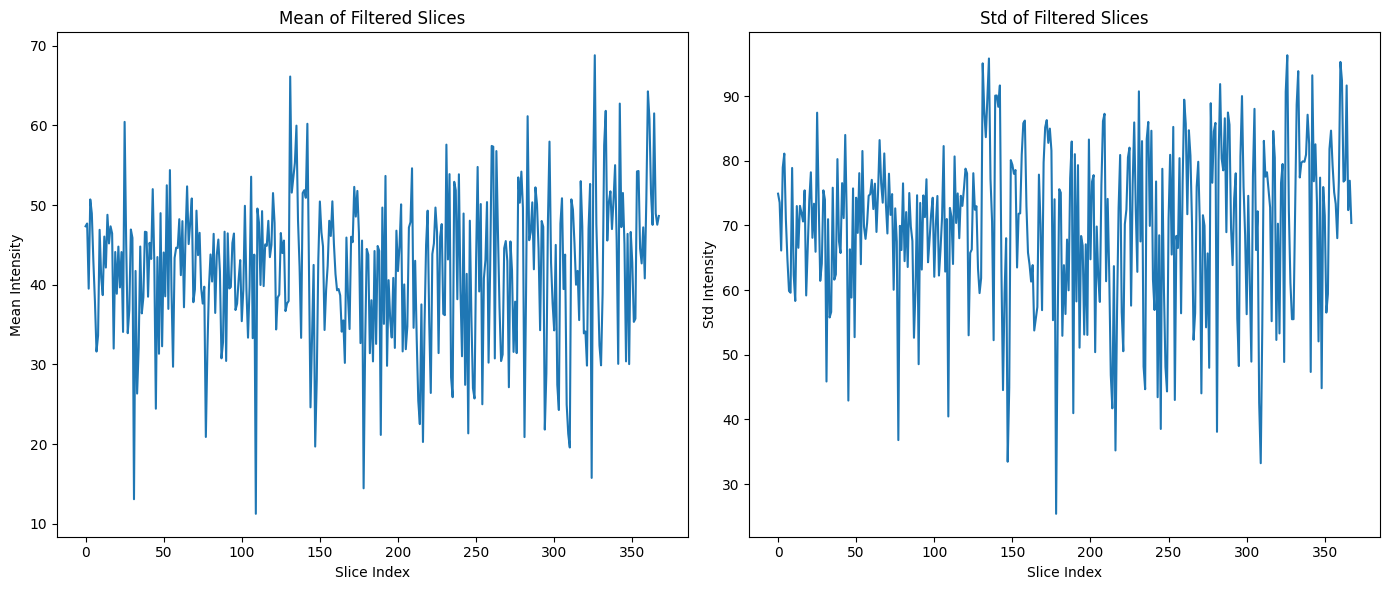

In [26]:
df = pd.DataFrame(stats_list)

print('Training slice count:', df.shape[0])

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(df["mean"])
plt.title("Mean of Filtered Slices")
plt.xlabel("Slice Index")
plt.ylabel("Mean Intensity")

plt.subplot(1,2,2)
plt.plot(df["std"])
plt.title("Std of Filtered Slices")
plt.xlabel("Slice Index")
plt.ylabel("Std Intensity")

plt.tight_layout()
plt.show()

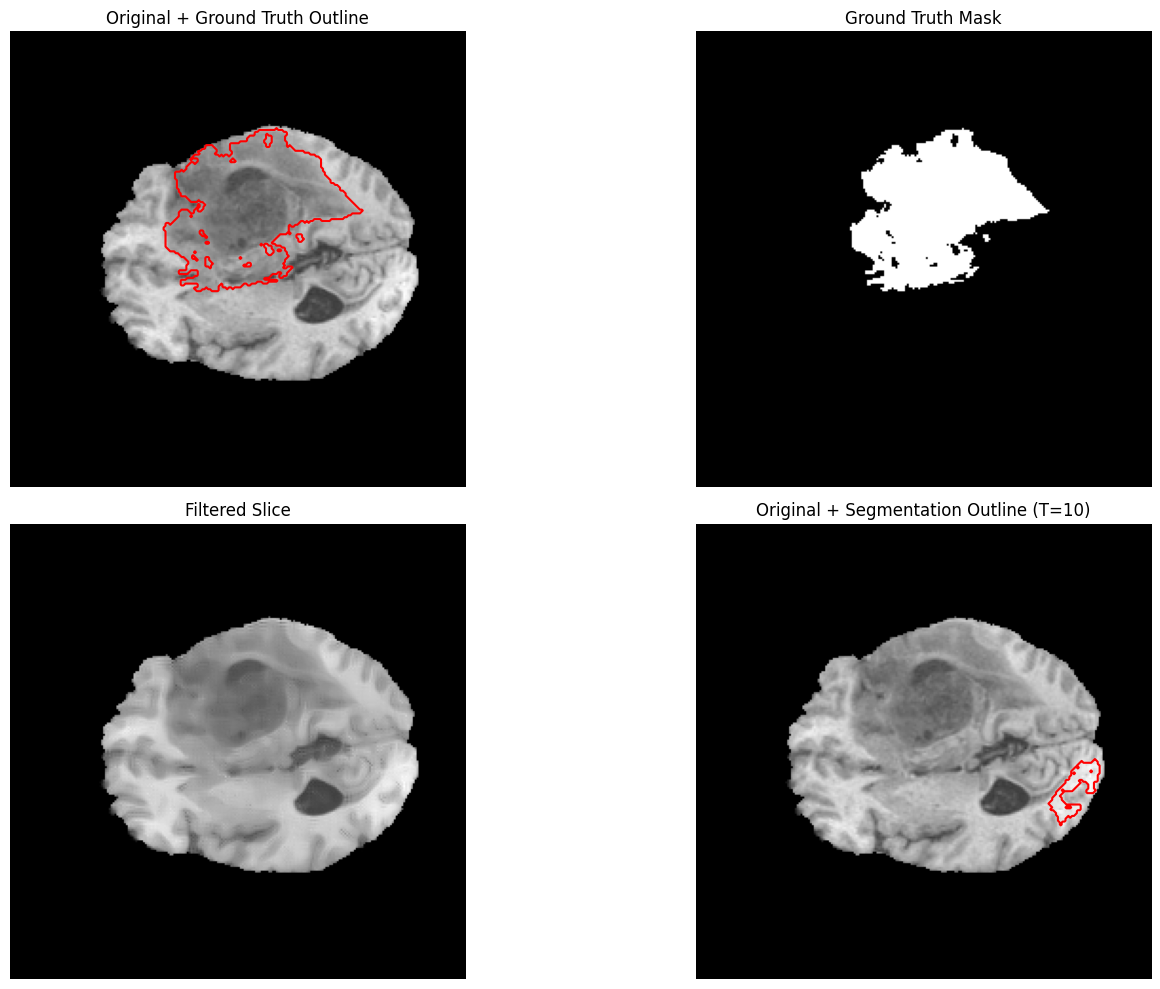

In [27]:
# visualize the first segmented case

# ensure we have at least one segmented case
if len(segmented_cases) == 0:
    print("No segmented cases available to plot")
else:
    sample = segmented_cases[0]
    img_orig = sample["img_orig"]
    img_filt = sample["img_filt"]
    gt_mask  = sample["mask_slice"]
    best_mask = sample["best_mask"]
    best_T = sample.get("best_T", None)

    # binary versions for contours
    gt_bin = (gt_mask > 0).astype(np.uint8)
    seg_bin = (best_mask > 0).astype(np.uint8)

    plt.figure(figsize=(16, 10))

    # Original + Ground Truth Outline
    plt.subplot(2, 2, 1)
    plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_GRAY2RGB))
    plt.contour(gt_bin, levels=[0.5], colors='red', linewidths=1.5)
    plt.title("Original + Ground Truth Outline")
    plt.axis('off')

    # Ground Truth Mask
    plt.subplot(2, 2, 2)
    plt.imshow(cv2.cvtColor(gt_mask, cv2.COLOR_GRAY2RGB))
    plt.title("Ground Truth Mask")
    plt.axis('off')

    # Filtered slice
    plt.subplot(2, 2, 3)
    plt.imshow(img_filt, cmap='gray')
    plt.title("Filtered Slice")
    plt.axis('off')

    # Original + Segmentation Outline
    plt.subplot(2, 2, 4)
    plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_GRAY2RGB))
    plt.contour(seg_bin, levels=[0.5], colors='red', linewidths=1.5)
    plt.title(f"Original + Segmentation Outline (T={best_T})")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [28]:
# evaluate segmented cases using Dice, IoU (Jaccard), and NSD

# initialize results_df2 as empty DataFrame to ensure it always exists
results_df2 = pd.DataFrame(columns=["case", "slice", "best_T", "dice", "iou", "nsd"])

# ensure segmented_cases exists and is not empty
if 'segmented_cases' not in globals() or not segmented_cases:
    print("No segmented cases found. Please run the segmentation pipeline first.")
else:
    eval_results = []
    count_considered = 0

    for sample in segmented_cases:
        gt_mask = (sample["mask_slice"] > 0).astype(np.uint8)
        pred_mask = (sample["best_mask"] > 0).astype(np.uint8)

        # skip slices with empty GT to avoid skewing evaluation
        if gt_mask.sum() == 0:
            continue

        count_considered += 1

        dsc = dice_coefficient(gt_mask, pred_mask)
        iou = jaccard_index_iou(gt_mask, pred_mask)
        nsd = normalized_surface_dice(pred_mask, gt_mask, tolerance=2)

        eval_results.append({
            "case": sample["case"],
            "slice": sample["slice"],
            "best_T": sample.get("best_T", None),
            "dice": dsc,
            "iou": iou,
            "nsd": nsd
        })

    results_df2 = pd.DataFrame(eval_results)

    print(f"Samples considered for evaluation: {count_considered}")
    if count_considered == 0:
        print("No samples with non-empty ground truth; skipping stats.")
    else:
        print(results_df2.describe())
        means = results_df2[["dice", "iou", "nsd"]].mean()
        print(f"\nMeans -- Dice: {means['dice']:.4f}, IoU: {means['iou']:.4f}, NSD: {means['nsd']:.4f}")

Samples considered for evaluation: 368
            slice      best_T          dice           iou         nsd
count  368.000000  368.000000  3.680000e+02  3.680000e+02  368.000000
mean    78.108696   18.750000  3.912718e-02  2.318016e-02    0.066606
std     17.469604   14.132402  1.003515e-01  6.355957e-02    0.165741
min     22.000000   10.000000  1.562256e-11  1.562256e-11    0.000000
25%     64.000000   10.000000  3.327313e-11  3.327313e-11    0.000000
50%     79.000000   10.000000  5.164033e-11  5.164033e-11    0.000000
75%     91.000000   21.250000  8.275499e-03  4.154941e-03    0.069378
max    128.000000   69.000000  6.684211e-01  5.019763e-01    1.000000

Means -- Dice: 0.0391, IoU: 0.0232, NSD: 0.0666


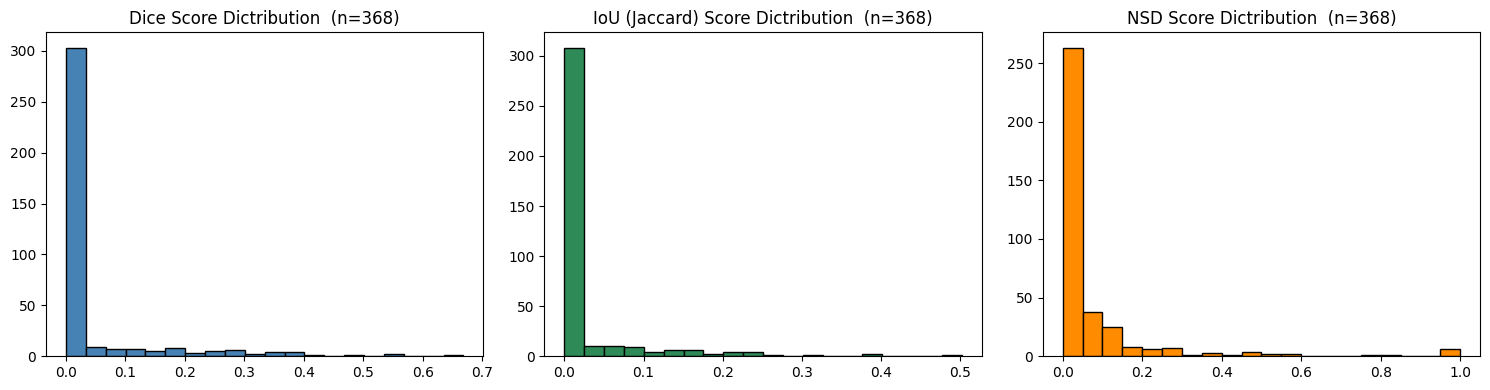

In [29]:
# histogram plots for evaluation metrics

# only proceed if results_df2 exists and has data
try:
    if results_df2 is None or results_df2.empty:
        raise ValueError("Empty results")
    n = len(results_df2)
except (NameError, ValueError):
    print("No evaluation results to plot histograms. Run the evaluation cell first.")
else:
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.hist(results_df2["dice"], bins=20, color='steelblue', edgecolor='black')
    plt.title(f"Dice Score Dictribution  (n={n})")

    plt.subplot(1, 3, 2)
    plt.hist(results_df2["iou"], bins=20, color='seagreen', edgecolor='black')
    plt.title(f"IoU (Jaccard) Score Dictribution  (n={n})")

    plt.subplot(1, 3, 3)
    plt.hist(results_df2["nsd"], bins=20, color='darkorange', edgecolor='black')
    plt.title(f"NSD Score Dictribution  (n={n})")

    plt.tight_layout()
    plt.show()

## T1CE

In [30]:
use_modality = 't1ce'

filtered_cases, stats_list = apply_anisotropic_filter_to_all(
    ALL_CASES_PATH, use_modality, num_iter=20, k=25, gamma=0.1, sigma=1.0)

segmented_cases = segment_cases(filtered_cases, delta=10.0)

Filtering: 100%|██████████| 369/369 [00:29<00:00, 12.72case/s]



Successfully applied anisotropic diffusion filter to all traning images


Segmentation: 100%|██████████| 368/368 [04:08<00:00,  1.48case/s]


In [31]:
# mean inference time

# mean times
filt_times = [c.get('filter_time_s', np.nan) for c in filtered_cases]
seg_times  = [c.get('segment_time_s', np.nan) for c in segmented_cases]

filt_times = np.array([t for t in filt_times if not np.isnan(t)])
seg_times  = np.array([t for t in seg_times if not np.isnan(t)])

mean_filter_time_ms  = (filt_times.mean()*1000.0) if filt_times.size else float('nan')
mean_segment_time_ms = (seg_times.mean()*1000.0) if seg_times.size else float('nan')
mean_total_time_ms   = mean_filter_time_ms + mean_segment_time_ms

print(f"Mean inference time per sample: {mean_total_time_ms:.2f} ms")
print(f"filter: {mean_filter_time_ms:.2f} ms, Segment: {mean_segment_time_ms:.2f} ms")

Mean inference time per sample: 645.44 ms
filter: 9.29 ms, Segment: 636.15 ms


Training slice count: 368


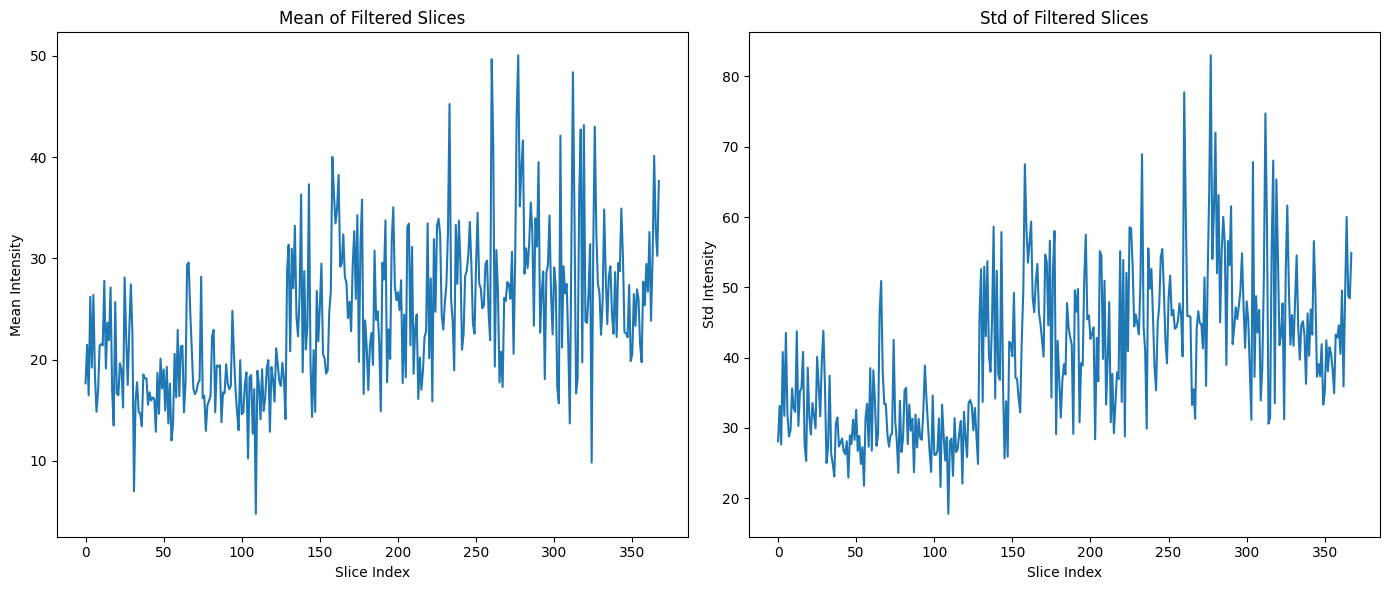

In [32]:
df = pd.DataFrame(stats_list)

print('Training slice count:', df.shape[0])

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(df["mean"])
plt.title("Mean of Filtered Slices")
plt.xlabel("Slice Index")
plt.ylabel("Mean Intensity")

plt.subplot(1,2,2)
plt.plot(df["std"])
plt.title("Std of Filtered Slices")
plt.xlabel("Slice Index")
plt.ylabel("Std Intensity")

plt.tight_layout()
plt.show()

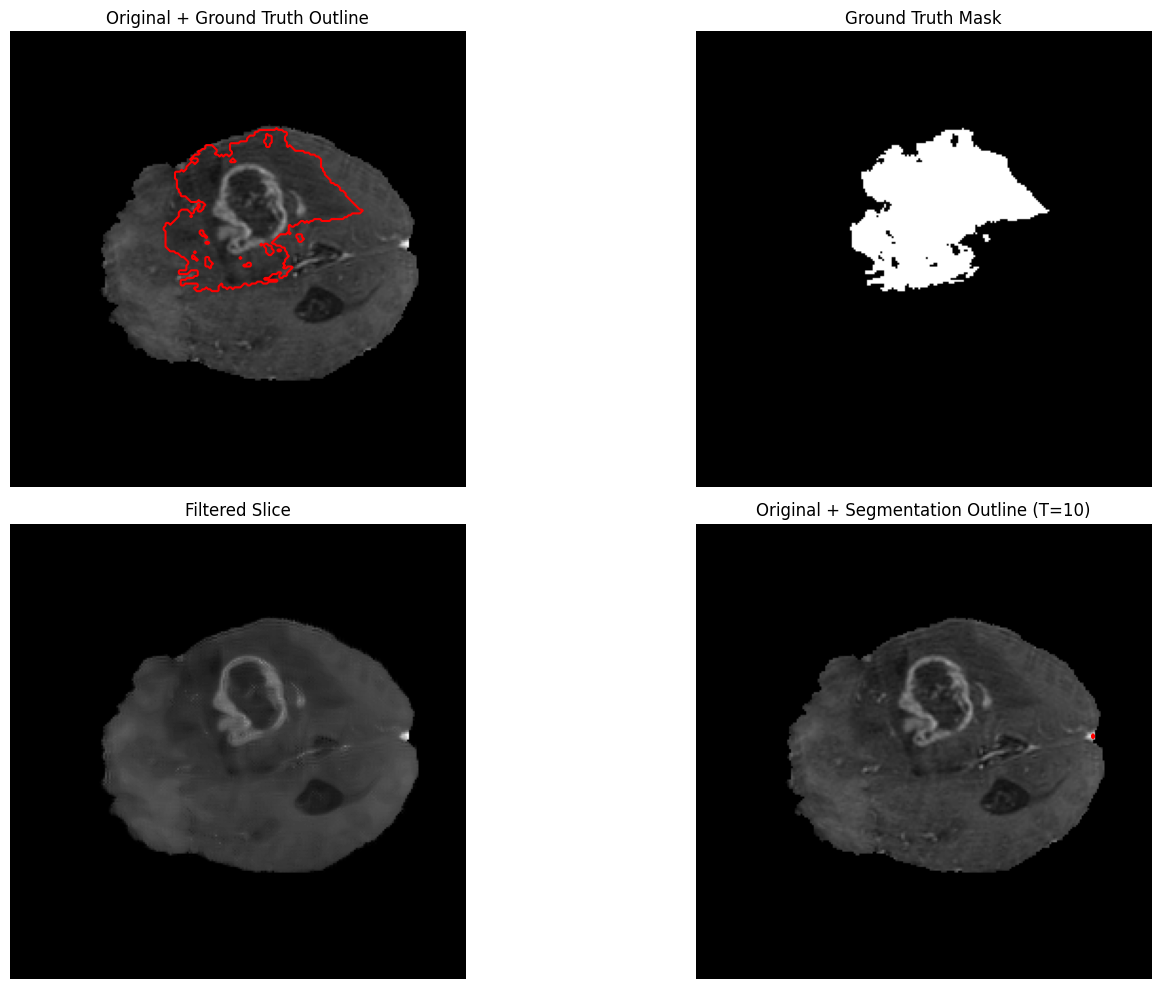

In [33]:
# visualize the first segmented case

# ensure we have at least one segmented case
if len(segmented_cases) == 0:
    print("No segmented cases available to plot")
else:
    sample = segmented_cases[0]
    img_orig = sample["img_orig"]
    img_filt = sample["img_filt"]
    gt_mask  = sample["mask_slice"]
    best_mask = sample["best_mask"]
    best_T = sample.get("best_T", None)

    # binary versions for contours
    gt_bin = (gt_mask > 0).astype(np.uint8)
    seg_bin = (best_mask > 0).astype(np.uint8)

    plt.figure(figsize=(16, 10))

    # Original + Ground Truth Outline
    plt.subplot(2, 2, 1)
    plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_GRAY2RGB))
    plt.contour(gt_bin, levels=[0.5], colors='red', linewidths=1.5)
    plt.title("Original + Ground Truth Outline")
    plt.axis('off')

    # Ground Truth Mask
    plt.subplot(2, 2, 2)
    plt.imshow(cv2.cvtColor(gt_mask, cv2.COLOR_GRAY2RGB))
    plt.title("Ground Truth Mask")
    plt.axis('off')

    # Filtered slice
    plt.subplot(2, 2, 3)
    plt.imshow(img_filt, cmap='gray')
    plt.title("Filtered Slice")
    plt.axis('off')

    # Original + Segmentation Outline
    plt.subplot(2, 2, 4)
    plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_GRAY2RGB))
    plt.contour(seg_bin, levels=[0.5], colors='red', linewidths=1.5)
    plt.title(f"Original + Segmentation Outline (T={best_T})")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [34]:
# evaluate segmented cases using Dice, IoU (Jaccard), and NSD

# initialize results_df2 as empty DataFrame to ensure it always exists
results_df2 = pd.DataFrame(columns=["case", "slice", "best_T", "dice", "iou", "nsd"])

# ensure segmented_cases exists and is not empty
if 'segmented_cases' not in globals() or not segmented_cases:
    print("No segmented cases found. Please run the segmentation pipeline first.")
else:
    eval_results = []
    count_considered = 0

    for sample in segmented_cases:
        gt_mask = (sample["mask_slice"] > 0).astype(np.uint8)
        pred_mask = (sample["best_mask"] > 0).astype(np.uint8)

        # skip slices with empty GT to avoid skewing evaluation
        if gt_mask.sum() == 0:
            continue

        count_considered += 1

        dsc = dice_coefficient(gt_mask, pred_mask)
        iou = jaccard_index_iou(gt_mask, pred_mask)
        nsd = normalized_surface_dice(pred_mask, gt_mask, tolerance=2)

        eval_results.append({
            "case": sample["case"],
            "slice": sample["slice"],
            "best_T": sample.get("best_T", None),
            "dice": dsc,
            "iou": iou,
            "nsd": nsd
        })

    results_df2 = pd.DataFrame(eval_results)

    print(f"Samples considered for evaluation: {count_considered}")
    if count_considered == 0:
        print("No samples with non-empty ground truth; skipping stats.")
    else:
        print(results_df2.describe())
        means = results_df2[["dice", "iou", "nsd"]].mean()
        print(f"\nMeans -- Dice: {means['dice']:.4f}, IoU: {means['iou']:.4f}, NSD: {means['nsd']:.4f}")

Samples considered for evaluation: 368
            slice      best_T          dice           iou         nsd
count  368.000000  368.000000  3.680000e+02  3.680000e+02  368.000000
mean    78.108696   25.472826  5.691064e-02  3.382971e-02    0.056617
std     17.469604   17.335582  1.190440e-01  7.465589e-02    0.183951
min     22.000000   10.000000  1.554968e-11  1.554968e-11    0.000000
25%     64.000000   10.000000  4.322922e-11  4.322922e-11    0.000000
50%     79.000000   17.500000  8.186723e-11  8.186723e-11    0.000000
75%     91.000000   41.000000  2.368432e-02  1.198416e-02    0.000000
max    128.000000   69.000000  6.356589e-01  4.659091e-01    1.000000

Means -- Dice: 0.0569, IoU: 0.0338, NSD: 0.0566


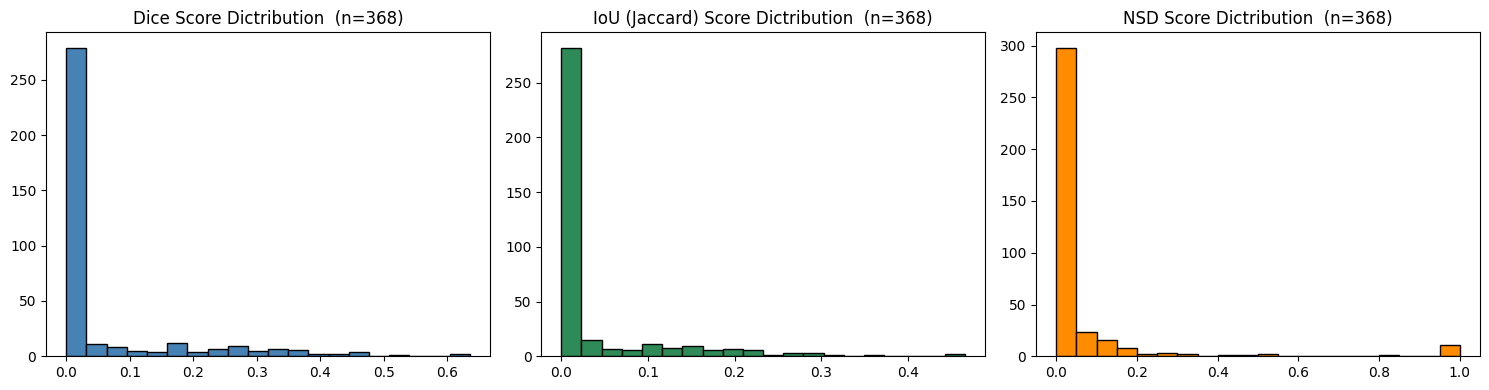

In [35]:
# histogram plots for evaluation metrics

# only proceed if results_df2 exists and has data
try:
    if results_df2 is None or results_df2.empty:
        raise ValueError("Empty results")
    n = len(results_df2)
except (NameError, ValueError):
    print("No evaluation results to plot histograms. Run the evaluation cell first.")
else:
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.hist(results_df2["dice"], bins=20, color='steelblue', edgecolor='black')
    plt.title(f"Dice Score Dictribution  (n={n})")

    plt.subplot(1, 3, 2)
    plt.hist(results_df2["iou"], bins=20, color='seagreen', edgecolor='black')
    plt.title(f"IoU (Jaccard) Score Dictribution  (n={n})")

    plt.subplot(1, 3, 3)
    plt.hist(results_df2["nsd"], bins=20, color='darkorange', edgecolor='black')
    plt.title(f"NSD Score Dictribution  (n={n})")

    plt.tight_layout()
    plt.show()

## T2

In [36]:
use_modality = 't2'

filtered_cases, stats_list = apply_anisotropic_filter_to_all(
    ALL_CASES_PATH, use_modality, num_iter=20, k=25, gamma=0.1, sigma=1.0)

segmented_cases = segment_cases(filtered_cases, delta=10.0)

Filtering: 100%|██████████| 369/369 [00:27<00:00, 13.26case/s]



Successfully applied anisotropic diffusion filter to all traning images


Segmentation: 100%|██████████| 368/368 [03:35<00:00,  1.70case/s]


In [37]:
# mean inference time

# mean times
filt_times = [c.get('filter_time_s', np.nan) for c in filtered_cases]
seg_times  = [c.get('segment_time_s', np.nan) for c in segmented_cases]

filt_times = np.array([t for t in filt_times if not np.isnan(t)])
seg_times  = np.array([t for t in seg_times if not np.isnan(t)])

mean_filter_time_ms  = (filt_times.mean()*1000.0) if filt_times.size else float('nan')
mean_segment_time_ms = (seg_times.mean()*1000.0) if seg_times.size else float('nan')
mean_total_time_ms   = mean_filter_time_ms + mean_segment_time_ms

print(f"Mean inference time per sample: {mean_total_time_ms:.2f} ms")
print(f"filter: {mean_filter_time_ms:.2f} ms, Segment: {mean_segment_time_ms:.2f} ms")

Mean inference time per sample: 555.17 ms
filter: 8.90 ms, Segment: 546.27 ms


Training slice count: 368


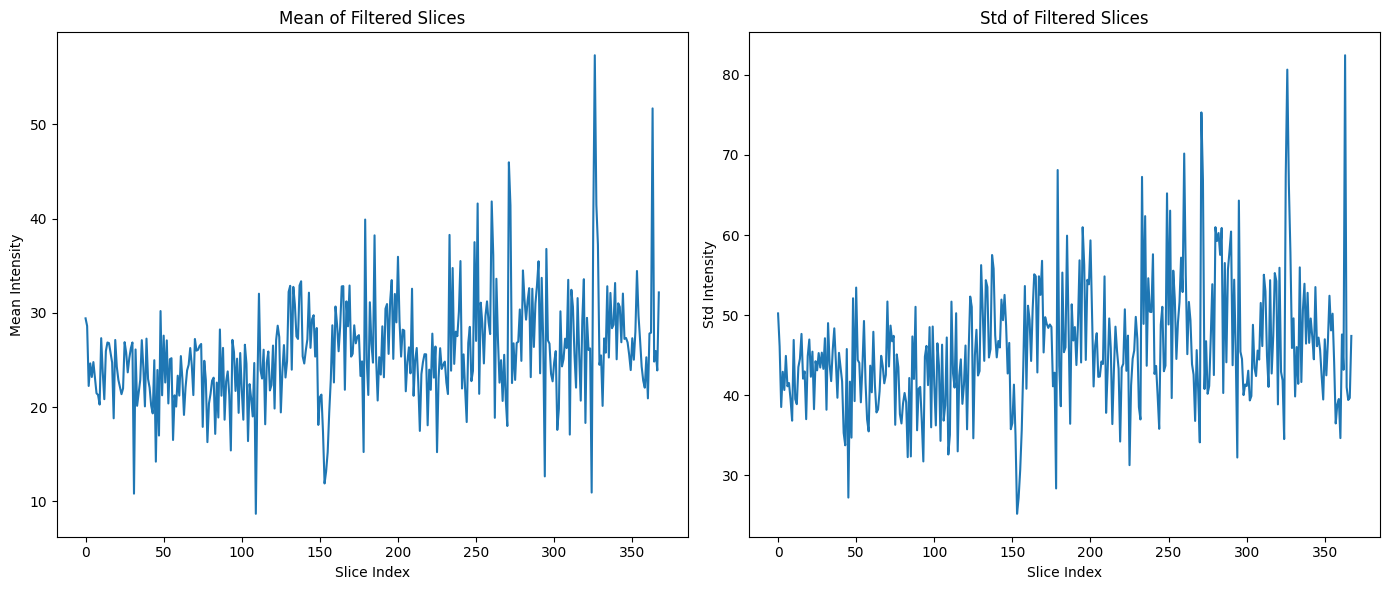

In [38]:
df = pd.DataFrame(stats_list)

print('Training slice count:', df.shape[0])

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(df["mean"])
plt.title("Mean of Filtered Slices")
plt.xlabel("Slice Index")
plt.ylabel("Mean Intensity")

plt.subplot(1,2,2)
plt.plot(df["std"])
plt.title("Std of Filtered Slices")
plt.xlabel("Slice Index")
plt.ylabel("Std Intensity")

plt.tight_layout()
plt.show()

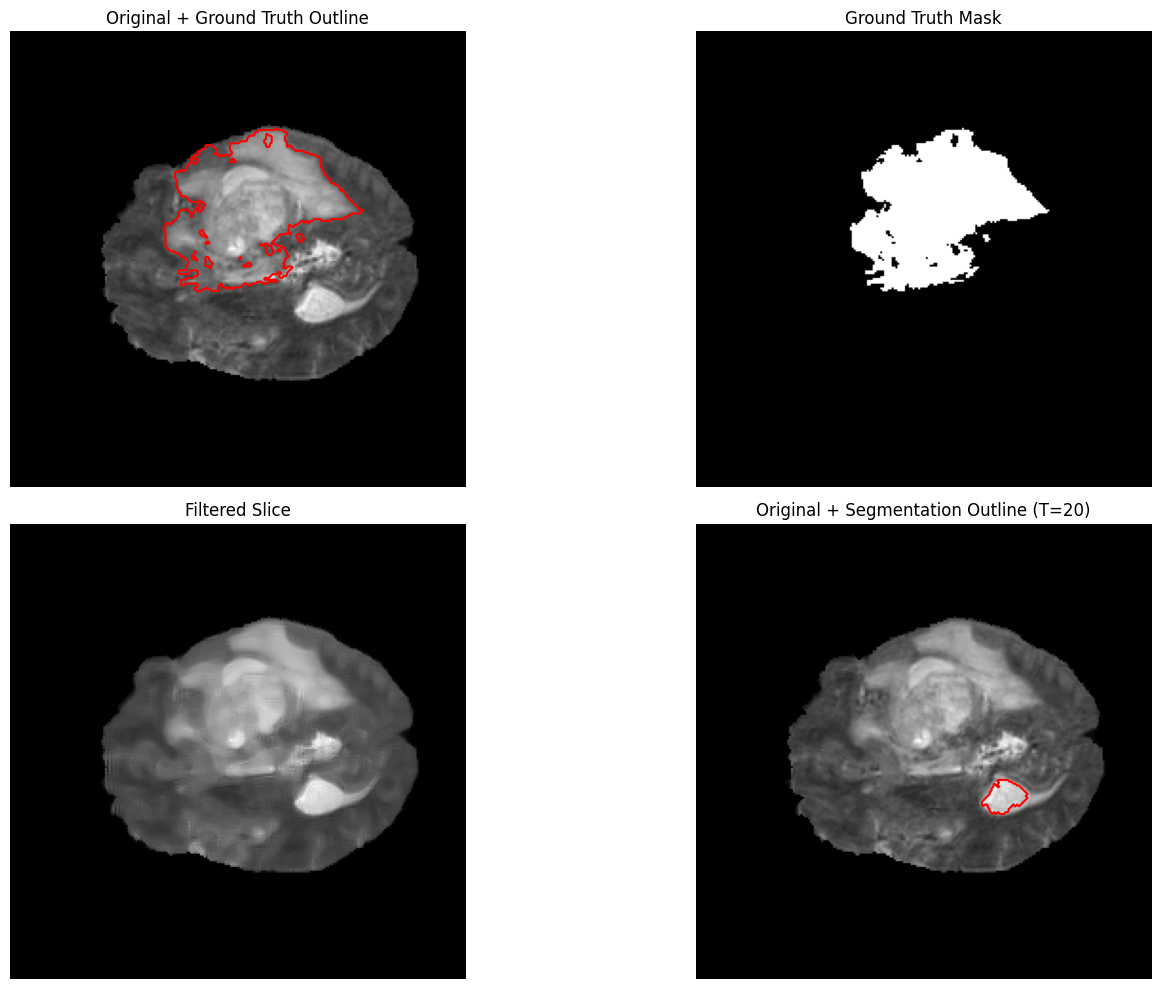

In [39]:
# visualize the first segmented case

# ensure we have at least one segmented case
if len(segmented_cases) == 0:
    print("No segmented cases available to plot")
else:
    sample = segmented_cases[0]
    img_orig = sample["img_orig"]
    img_filt = sample["img_filt"]
    gt_mask  = sample["mask_slice"]
    best_mask = sample["best_mask"]
    best_T = sample.get("best_T", None)

    # binary versions for contours
    gt_bin = (gt_mask > 0).astype(np.uint8)
    seg_bin = (best_mask > 0).astype(np.uint8)

    plt.figure(figsize=(16, 10))

    # Original + Ground Truth Outline
    plt.subplot(2, 2, 1)
    plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_GRAY2RGB))
    plt.contour(gt_bin, levels=[0.5], colors='red', linewidths=1.5)
    plt.title("Original + Ground Truth Outline")
    plt.axis('off')

    # Ground Truth Mask
    plt.subplot(2, 2, 2)
    plt.imshow(cv2.cvtColor(gt_mask, cv2.COLOR_GRAY2RGB))
    plt.title("Ground Truth Mask")
    plt.axis('off')

    # Filtered slice
    plt.subplot(2, 2, 3)
    plt.imshow(img_filt, cmap='gray')
    plt.title("Filtered Slice")
    plt.axis('off')

    # Original + Segmentation Outline
    plt.subplot(2, 2, 4)
    plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_GRAY2RGB))
    plt.contour(seg_bin, levels=[0.5], colors='red', linewidths=1.5)
    plt.title(f"Original + Segmentation Outline (T={best_T})")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [40]:
# evaluate segmented cases using Dice, IoU (Jaccard), and NSD

# initialize results_df2 as empty DataFrame to ensure it always exists
results_df2 = pd.DataFrame(columns=["case", "slice", "best_T", "dice", "iou", "nsd"])

# ensure segmented_cases exists and is not empty
if 'segmented_cases' not in globals() or not segmented_cases:
    print("No segmented cases found. Please run the segmentation pipeline first.")
else:
    eval_results = []
    count_considered = 0

    for sample in segmented_cases:
        gt_mask = (sample["mask_slice"] > 0).astype(np.uint8)
        pred_mask = (sample["best_mask"] > 0).astype(np.uint8)

        # skip slices with empty GT to avoid skewing evaluation
        if gt_mask.sum() == 0:
            continue

        count_considered += 1

        dsc = dice_coefficient(gt_mask, pred_mask)
        iou = jaccard_index_iou(gt_mask, pred_mask)
        nsd = normalized_surface_dice(pred_mask, gt_mask, tolerance=2)

        eval_results.append({
            "case": sample["case"],
            "slice": sample["slice"],
            "best_T": sample.get("best_T", None),
            "dice": dsc,
            "iou": iou,
            "nsd": nsd
        })

    results_df2 = pd.DataFrame(eval_results)

    print(f"Samples considered for evaluation: {count_considered}")
    if count_considered == 0:
        print("No samples with non-empty ground truth; skipping stats.")
    else:
        print(results_df2.describe())
        means = results_df2[["dice", "iou", "nsd"]].mean()
        print(f"\nMeans -- Dice: {means['dice']:.4f}, IoU: {means['iou']:.4f}, NSD: {means['nsd']:.4f}")

Samples considered for evaluation: 368
            slice      best_T          dice           iou         nsd
count  368.000000  368.000000  3.680000e+02  3.680000e+02  368.000000
mean    78.108696   16.690217  4.815091e-02  2.930245e-02    0.020764
std     17.469604   12.130162  1.169191e-01  7.813506e-02    0.085304
min     22.000000   10.000000  1.514463e-11  1.514463e-11    0.000000
25%     64.000000   10.000000  3.556508e-11  3.556508e-11    0.000000
50%     79.000000   10.000000  5.807483e-11  5.807483e-11    0.000000
75%     91.000000   18.000000  1.791117e-02  9.036525e-03    0.000000
max    128.000000   68.000000  7.140707e-01  5.552955e-01    1.000000

Means -- Dice: 0.0482, IoU: 0.0293, NSD: 0.0208


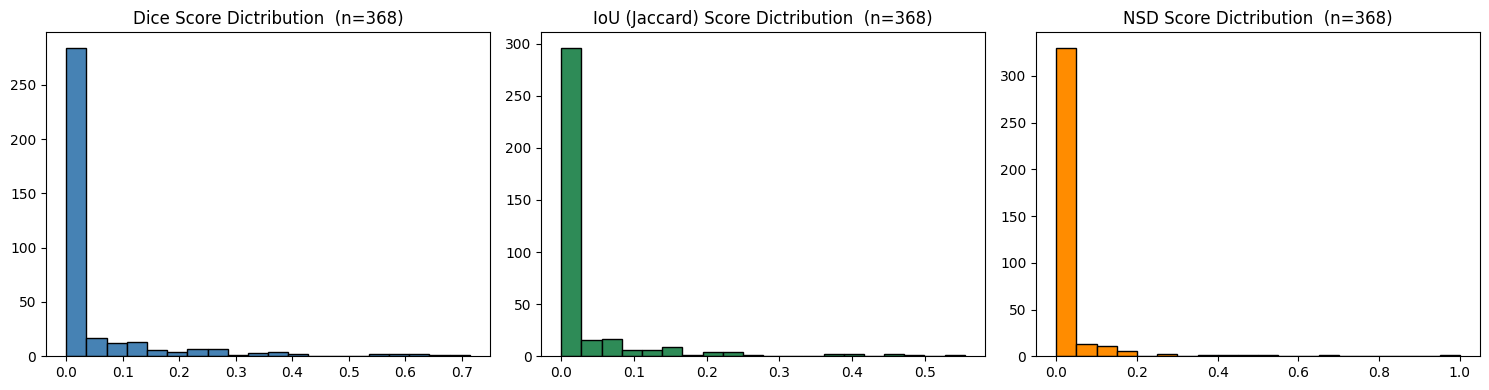

In [41]:
# histogram plots for evaluation metrics

# only proceed if results_df2 exists and has data
try:
    if results_df2 is None or results_df2.empty:
        raise ValueError("Empty results")
    n = len(results_df2)
except (NameError, ValueError):
    print("No evaluation results to plot histograms. Run the evaluation cell first.")
else:
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.hist(results_df2["dice"], bins=20, color='steelblue', edgecolor='black')
    plt.title(f"Dice Score Dictribution  (n={n})")

    plt.subplot(1, 3, 2)
    plt.hist(results_df2["iou"], bins=20, color='seagreen', edgecolor='black')
    plt.title(f"IoU (Jaccard) Score Dictribution  (n={n})")

    plt.subplot(1, 3, 3)
    plt.hist(results_df2["nsd"], bins=20, color='darkorange', edgecolor='black')
    plt.title(f"NSD Score Dictribution  (n={n})")

    plt.tight_layout()
    plt.show()